# Klasifikimi i Imazheve HAM10000 me Decision Tree (Peme Vendimesh)

Ky notebook perdor datasetin e filtruar HAM10000 per te trajnuar nje model klasifikimi binar (`mel` vs `nv`) duke perdorur algoritmin **Decision Tree** (Peme Vendimesh).

Modeli merr si input dy lloje karakteristikash:
1. **Imazhet**: te cilat ndryshohen ne permasa `32x32` piksela, kthehen ne vektore te sheshte (flattened) dhe normalizohen.
2. **Metadata**: duke perfshire moshen, gjinine dhe lokalizimin e lesionit (te koduara me One-Hot Encoding).

### 1. Importimi i bibliotekave te nevojshme

In [1]:
%pip install pandas numpy pillow scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

### 2. Percaktimi i folderave (Paths)

In [3]:
BASE_DIR = os.getcwd()

METADATA_PATH = os.path.join(
    BASE_DIR,
    "HAM10000_metadata_filtered.csv"
)

MEL_DIR = os.path.join(
    BASE_DIR,
    "mel"
)

NV_DIR = os.path.join(
    BASE_DIR,
    "nv"
)

print("Base directory:", BASE_DIR)

Base directory: c:\Users\Dell\OneDrive\Desktop\DermaScan\ham_dataset


### 3. Ngarkimi dhe pastrimi i Metadata

In [4]:
# Ngarkojme CSV
df = pd.read_csv(METADATA_PATH)
print(f"Numri total i rreshtave ne metadata: {len(df)}")

# 1. Mbushim vlerat qe mungojne per age me mesataren
mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

# 2. Kodojme kolonat kategoriale (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['sex', 'localization'], drop_first=True)

# 3. Krijojme etiketen target: nv -> 0 (nevi), mel -> 1 (melanoma)
df_encoded['label'] = df_encoded['dx'].map({'nv': 0, 'mel': 1})

print("Kolonat pas kodimit:")
print(df_encoded.columns.tolist())
df_encoded.head()

Numri total i rreshtave ne metadata: 2226
Kolonat pas kodimit:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex_male', 'sex_unknown', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity', 'label']


,lesion_id,image_id,dx,dx_type,age,sex_male,sex_unknown,localization_acral,localization_back,localization_chest,...,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity,label
0,HAM_0000871,ISIC_0025964,mel,histo,40.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
1,HAM_0000871,ISIC_0030623,mel,histo,40.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
2,HAM_0000040,ISIC_0027190,mel,histo,80.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
3,HAM_0005678,ISIC_0031023,mel,histo,60.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
4,HAM_0005678,ISIC_0028086,mel,histo,60.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1


### 4. Ngarkimi i imazheve dhe ekstraktimi i karakteristikave

In [5]:
images = []
labels = []
meta_features = []

# Kolonat qe duhen perjashtuar nga metadata per te marre vetem tiparet e pastra
exclude_cols = ['lesion_id', 'image_id', 'dx', 'dx_type', 'label']
meta_cols = [col for col in df_encoded.columns if col not in exclude_cols]

print("Duke ngarkuar fotot dhe duke nxjerre tiparet...")
for idx, row in df_encoded.iterrows():
    img_id = row['image_id']
    label = row['label']
    
    # Kerko foton te mel ose nv
    img_path = os.path.join(MEL_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(NV_DIR, f"{img_id}.jpg")
        
    if os.path.exists(img_path):
        with Image.open(img_path) as img:
            # Resize ne 32x32 dhe konvertim ne RGB
            img_resized = img.resize((32, 32)).convert('RGB')
            # Flatten dhe normalizim [0, 1]
            img_array = np.array(img_resized).flatten() / 255.0
            
            images.append(img_array)
            labels.append(label)
            meta_features.append(row[meta_cols].values.astype(float))
    else:
        print(f"Warning: Fotoja {img_id}.jpg nuk u gjet!")

X_img = np.array(images)
X_meta = np.array(meta_features)
y = np.array(labels)

print(f"Dimensioni i matrices se fotove: {X_img.shape}")
print(f"Dimensioni i matrices se metadata: {X_meta.shape}")
print(f"Dimensioni i target label y: {y.shape}")

Duke ngarkuar fotot dhe duke nxjerre tiparet...
Dimensioni i matrices se fotove: (2226, 3072)
Dimensioni i matrices se metadata: (2226, 17)
Dimensioni i target label y: (2226,)


### 5. Bashkimi i karakteristikave (Feature Fusion) dhe ndarja e datasetit

In [6]:
# Bashkojme tiparet horizontally
X = np.hstack((X_img, X_meta))
print(f"Dimensioni total i matrices se inputit X: {X.shape}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Madhesia e Train Set: {X_train.shape[0]}")
print(f"Madhesia e Test Set: {X_test.shape[0]}")

Dimensioni total i matrices se inputit X: (2226, 3089)
Madhesia e Train Set: 1780
Madhesia e Test Set: 446


### 6. Tuning i max_depth per te shmangur overfitting

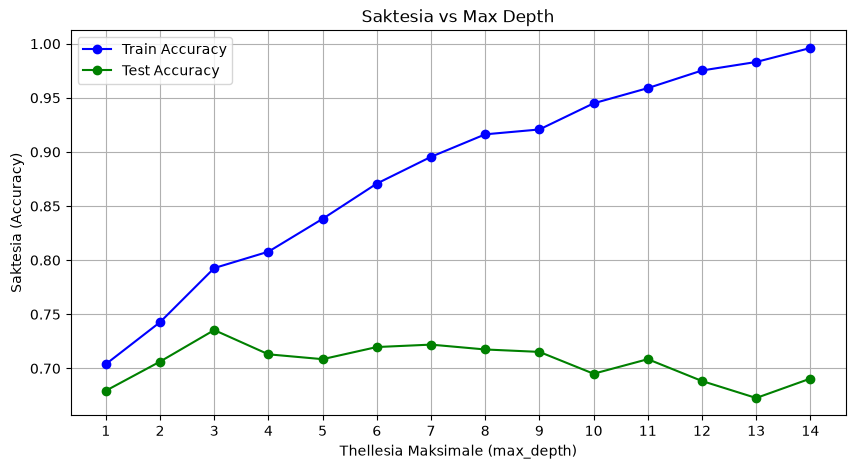

max_depth optimal është 3 me saktësi 0.7354 në test set.


In [7]:
depths = range(1, 15)
train_accs = []
test_accs = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

# Vizualizimi
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, label='Train Accuracy', marker='o', color='blue')
plt.plot(depths, test_accs, label='Test Accuracy', marker='o', color='green')
plt.xlabel('Thellesia Maksimale (max_depth)')
plt.ylabel('Saktesia (Accuracy)')
plt.title('Saktesia vs Max Depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

best_d = depths[np.argmax(test_accs)]
print(f"max_depth optimal është {best_d} me saktësi {max(test_accs):.4f} në test set.")

### 7. Trajnimi i modelit final

In [8]:
optimal_depth = min(best_d, 6)
print(f"Duke trajnuar modelin e fundit me max_depth={optimal_depth}...")

model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
model.fit(X_train, y_train)

Duke trajnuar modelin e fundit me max_depth=3...


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### 8. Vleresimi i modelit final

Saktesia ne Test Set: 0.7354

Raporti i Klasifikimit:
                precision    recall  f1-score   support

    nv (Nevus)       0.73      0.74      0.74       223
mel (Melanoma)       0.74      0.73      0.73       223

      accuracy                           0.74       446
     macro avg       0.74      0.74      0.74       446
  weighted avg       0.74      0.74      0.74       446



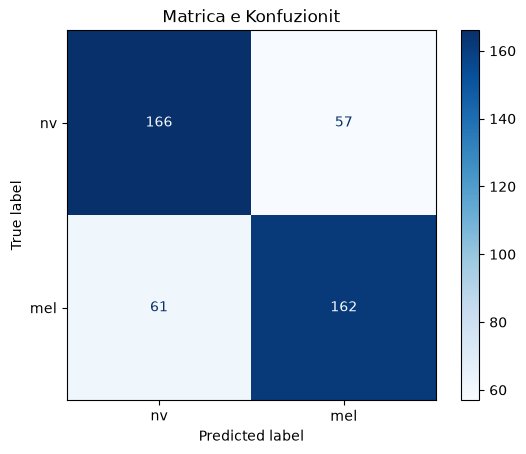

In [9]:
y_pred = model.predict(X_test)

# Saktesia
print(f"Saktesia ne Test Set: {accuracy_score(y_test, y_pred):.4f}\n")

# Classification Report
print("Raporti i Klasifikimit:")
print(classification_report(y_test, y_pred, target_names=['nv (Nevus)', 'mel (Melanoma)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['nv', 'mel'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrica e Konfuzionit")
plt.show()

### 9. Rendesia e karakteristikave (Feature Importance)

In [10]:
importances = model.feature_importances_
num_pixels = X_img.shape[1]

pixel_imp_sum = np.sum(importances[:num_pixels])
meta_imp = importances[num_pixels:]

print(f"Rendesia e pergjithshme e pikselave te imazheve: {pixel_imp_sum:.4f}")
print("\nRendesia e karakteristikave te metadata:")
for col, imp in zip(meta_cols, meta_imp):
    if imp > 0:
        print(f" - {col}: {imp:.4f}")

Rendesia e pergjithshme e pikselave te imazheve: 0.7171

Rendesia e karakteristikave te metadata:
 - age: 0.2829


### 10. Vizualizimi i pershtatshem i pemes (Structure Visualization)

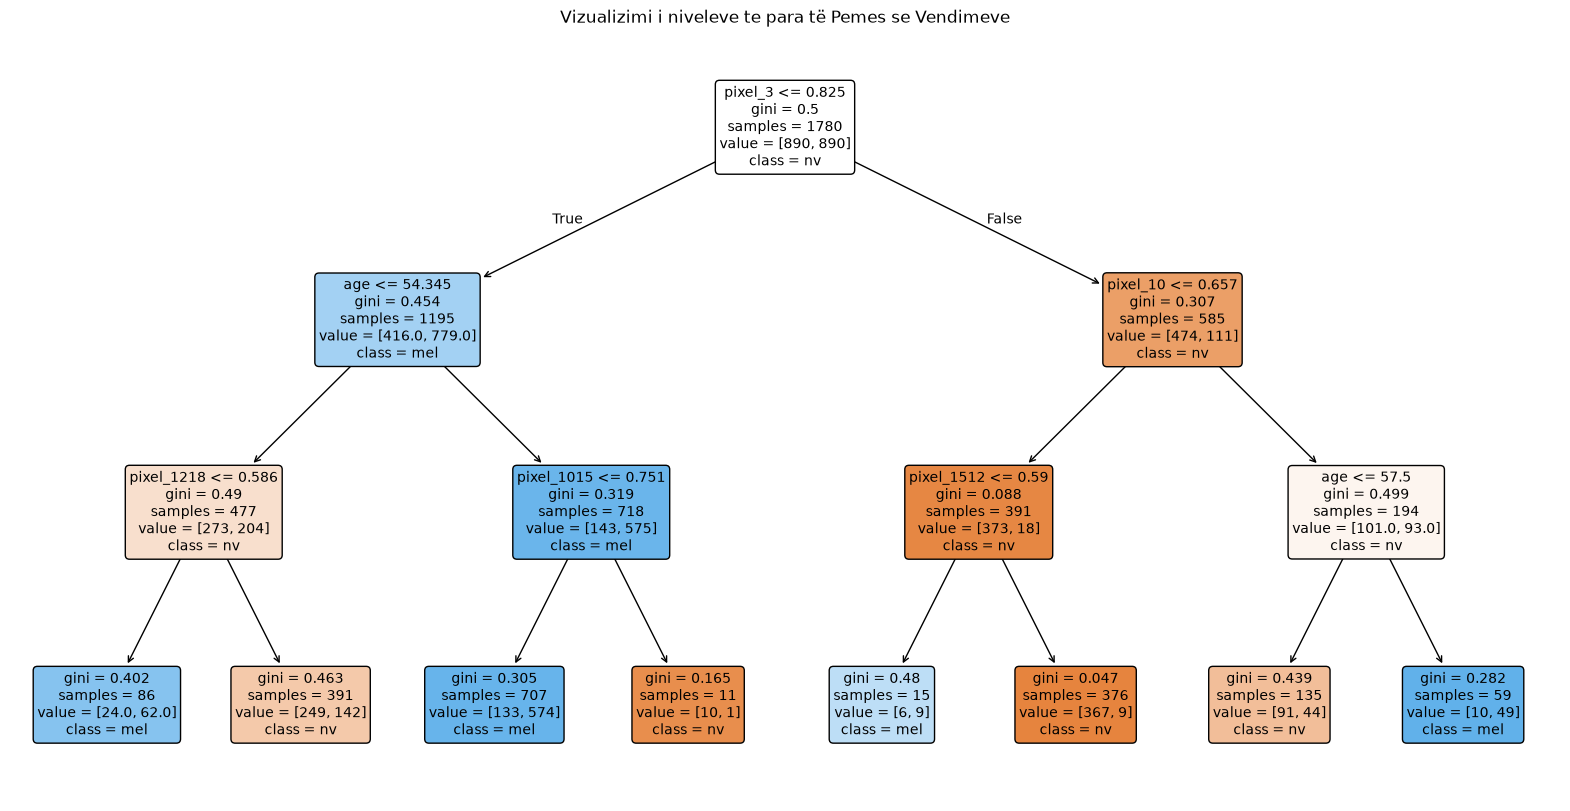

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,
    feature_names=[f"pixel_{i}" for i in range(num_pixels)] + meta_cols,
    class_names=['nv', 'mel'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Vizualizimi i niveleve te para të Pemes se Vendimeve")
plt.show()

### 11. Ruajtja e modelit të trajnuar

In [12]:
model_path = os.path.join(BASE_DIR, "decision_tree_model.pkl")
joblib.dump(model, model_path)
print(f"Modeli u ruajt me sukses ne: {model_path}")

Modeli u ruajt me sukses ne: c:\Users\Dell\OneDrive\Desktop\DermaScan\ham_dataset\decision_tree_model.pkl
